In [1]:
%pip install -q nltk wordcloud gradio
import re, os, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import nltk
warnings.filterwarnings("ignore")
for p in ["stopwords","wordnet","omw-1.4","vader_lexicon","punkt","punkt_tab"]:
    nltk.download(p, quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [3]:
from google.colab import files
DATA_PATH = list(files.upload().keys())[0]   # choose amazon.csv

df = pd.read_csv(DATA_PATH)
df.columns = ["text", "label"]
df["sentiment"] = df["label"].map({1: "Positive", 0: "Negative"})
df["n_words"] = df["text"].str.split().str.len()
print(df.shape, "| duplicates:", df.text.duplicated().sum())
print(df.sentiment.value_counts(normalize=True).round(3))
df.sample(5, random_state=42)

Saving amazon (1).csv to amazon (1).csv
(19996, 4) | duplicates: 0
sentiment
Positive    0.762
Negative    0.238
Name: proportion, dtype: float64


,text,label,sentiment,n_words
18883,WORST APP EVER!! Don't get if you have a Kindl...,0,Negative,24
2140,"This app is a pretty good app, I have a great ...",1,Positive,51
6110,Hopefully this will get fixed. Force close on ...,0,Negative,22
14526,Great fun. This game is challenging and addict...,1,Positive,29
10865,It is really nice to see an app done right. Th...,1,Positive,30


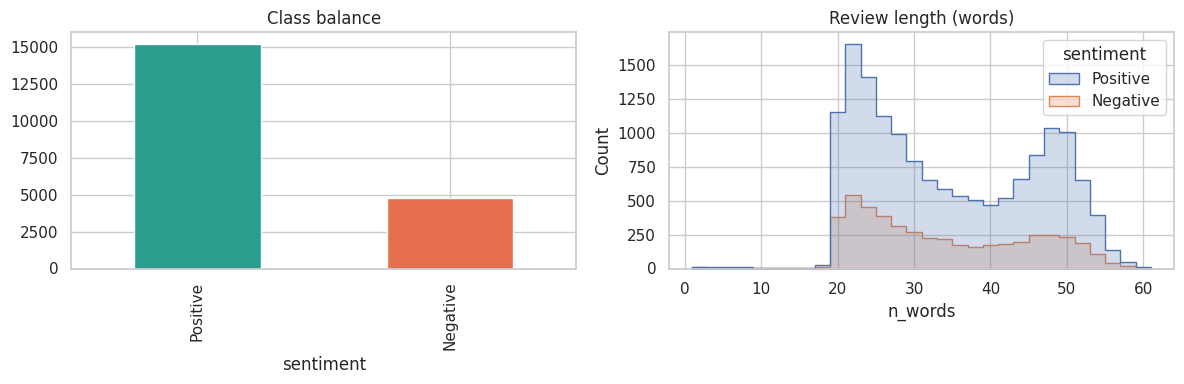

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df.sentiment.value_counts().plot.bar(ax=ax[0], color=["#2a9d8f", "#e76f51"], title="Class balance")
sns.histplot(data=df, x="n_words", hue="sentiment", bins=30, element="step", ax=ax[1])
ax[1].set_title("Review length (words)")
plt.tight_layout(); plt.show()

In [5]:
STOP = set(stopwords.words("english")) - {"no","not","nor","never","too","very","only","against"}
DOMAIN_STOP = {"app","apps","game","games","quot","amp","get","got","one","would","could","also"}
lem = WordNetLemmatizer()

def clean_text(t):
    t = str(t).lower().replace("’", "'")
    t = re.sub(r"&quot;|&amp;|&[a-z]+;|<[^>]+>|http\S+", " ", t)
    t = re.sub(r"\bwon'?t\b", "will not", t)
    t = re.sub(r"\bcan'?t\b|\bcannot\b", "can not", t)
    t = re.sub(r"\b(do|does|did|is|are|was|were|has|have|had|would|should|could|need|must)n'?t\b", r"\1 not", t)
    t = re.sub(r"[^a-z\s]", " ", t)
    return re.sub(r"\s+", " ", t).strip()

def tokens(t, drop_domain=False):
    out = []
    for w in clean_text(t).split():
        if w in STOP or len(w) < 2: continue
        w = lem.lemmatize(lem.lemmatize(w, "v"), "n")
        if drop_domain and w in DOMAIN_STOP: continue
        out.append(w)
    return out

df["clean"] = df["text"].apply(clean_text)                           # for VADER and themes
df["processed"] = df["text"].apply(lambda t: " ".join(tokens(t)))    # for ML
pd.set_option("display.max_colwidth", 150)
df[["text", "processed"]].sample(3, random_state=7)

,text,processed
1628,"I dont know how anyone can not like this site lol I use it on my laptop, kindle and my cell phone. Love it!!",not know anyone not like site lol use laptop kindle cell phone love
833,"This game is also a lot of fun,on my Kindle fire HDI can see the cute expression on there little faces when they crash...lol",game also lot fun kindle fire hdi see cute expression little face crash lol
3921,"We had these books for our kids, now we have them for our grandkids. Have to find all the spiders, frogs and mice again. I love the stories and i...",book kid grandkids find spider frog mouse love story illustration would buy additional release


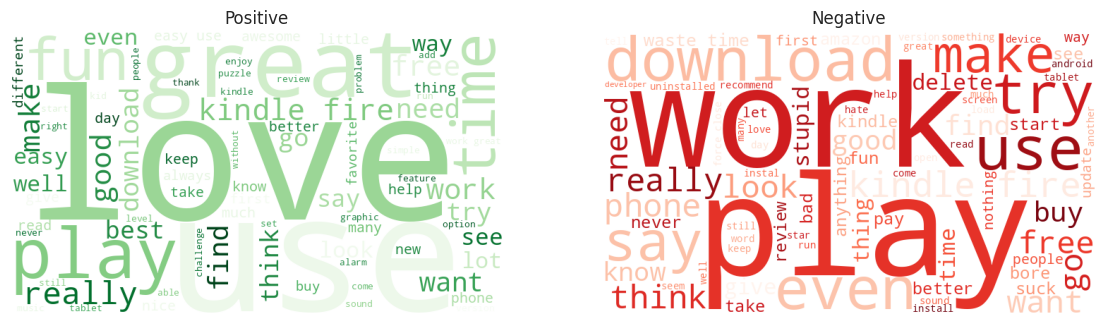

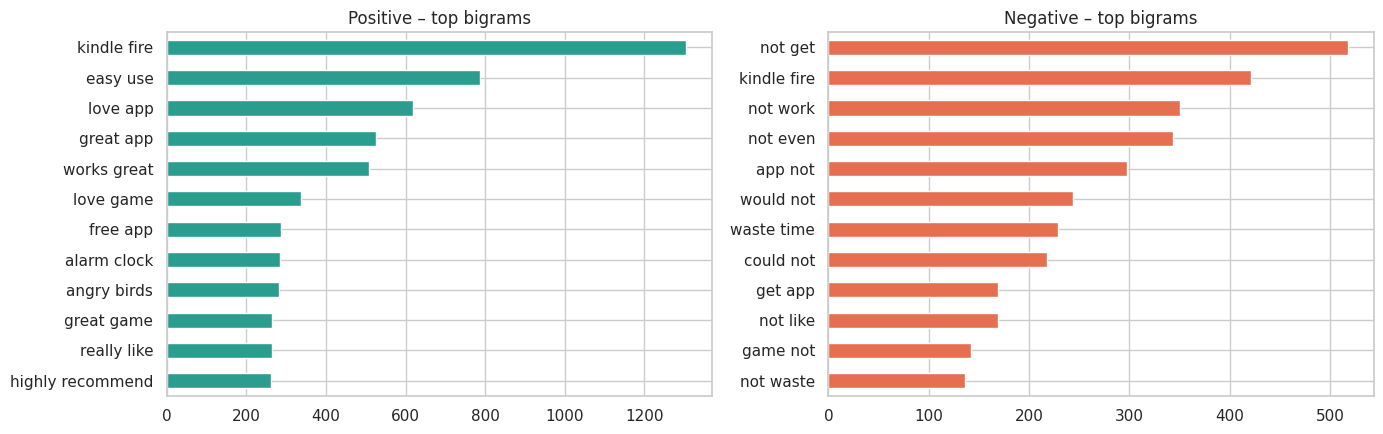

In [6]:
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for a, (lab, cmap) in zip(ax, [(1, "Greens"), (0, "Reds")]):
    txt = " ".join(" ".join(tokens(t, True)) for t in df[df.label == lab]["text"].sample(4000, random_state=1))
    a.imshow(WordCloud(width=700, height=400, background_color="white", colormap=cmap, max_words=80).generate(txt))
    a.set_title("Positive" if lab else "Negative"); a.axis("off")
plt.show()

def top_bigrams(texts, k=12):
    cv = CountVectorizer(ngram_range=(2,2), stop_words=list(STOP - {"not","no","never"}), min_df=5)
    X = cv.fit_transform(texts)
    return pd.Series(np.asarray(X.sum(0)).ravel(), index=cv.get_feature_names_out()).nlargest(k)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
for a, (lab, col) in zip(ax, [(1, "#2a9d8f"), (0, "#e76f51")]):
    top_bigrams(df[df.label == lab]["clean"])[::-1].plot.barh(ax=a, color=col)
    a.set_title(("Positive" if lab else "Negative") + " – top bigrams")
plt.tight_layout(); plt.show()

In [7]:
toy = ["the app crashes every time", "the app is great", "great app great graphics"]
bow, tf = CountVectorizer().fit(toy), TfidfVectorizer().fit(toy)
print("BoW counts");   display(pd.DataFrame(bow.transform(toy).toarray(), columns=bow.get_feature_names_out()))
print("TF-IDF weights"); display(pd.DataFrame(tf.transform(toy).toarray().round(2), columns=tf.get_feature_names_out()))

BoW counts


,app,crashes,every,graphics,great,is,the,time
0,1,1,1,0,0,0,1,1
1,1,0,0,0,1,1,1,0
2,1,0,0,1,2,0,0,0


TF-IDF weights


,app,crashes,every,graphics,great,is,the,time
0,0.30,0.5,0.5,0.00,0.00,0.00,0.38,0.5
1,0.37,0.0,0.0,0.00,0.48,0.63,0.48,0.0
2,0.31,0.0,0.0,0.52,0.79,0.00,0.00,0.0


In [8]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support, f1_score, roc_auc_score,
                             confusion_matrix, classification_report, roc_curve)

X_tr, X_te, y_tr, y_te = train_test_split(df["processed"], df["label"], test_size=0.2,
                                          stratify=df["label"], random_state=RANDOM_STATE)
bow_v   = lambda: CountVectorizer(ngram_range=(1,2), min_df=3)
tfidf_v = lambda: TfidfVectorizer(ngram_range=(1,2), min_df=3, sublinear_tf=True)
models = {
    "BoW + Naive Bayes":      Pipeline([("v", bow_v()),   ("c", MultinomialNB())]),
    "TF-IDF + Naive Bayes":   Pipeline([("v", tfidf_v()), ("c", MultinomialNB())]),
    "BoW + Logistic Reg.":    Pipeline([("v", bow_v()),   ("c", LogisticRegression(max_iter=2000, class_weight="balanced"))]),
    "TF-IDF + Logistic Reg.": Pipeline([("v", tfidf_v()), ("c", LogisticRegression(max_iter=2000, class_weight="balanced"))]),
    "TF-IDF + Linear SVM":    Pipeline([("v", tfidf_v()), ("c", LinearSVC(class_weight="balanced"))]),
}
rows = []
for name, m in models.items():
    m.fit(X_tr, y_tr); pred = m.predict(X_te)
    score = m.predict_proba(X_te)[:,1] if hasattr(m, "predict_proba") else m.decision_function(X_te)
    p, r, f, _ = precision_recall_fscore_support(y_te, pred, labels=[0], zero_division=0)
    rows.append({"Model": name, "Accuracy": accuracy_score(y_te, pred),
                 "Macro-F1": f1_score(y_te, pred, average="macro"),
                 "Neg. precision": p[0], "Neg. recall": r[0], "ROC-AUC": roc_auc_score(y_te, score)})
results = pd.DataFrame(rows).set_index("Model").round(3).sort_values("Macro-F1", ascending=False)
results

,Accuracy,Macro-F1,Neg. precision,Neg. recall,ROC-AUC
Model,,,,,
TF-IDF + Linear SVM,0.910,0.878,0.792,0.843,0.959
BoW + Logistic Reg.,0.906,0.875,0.778,0.849,0.956
TF-IDF + Logistic Reg.,0.900,0.871,0.745,0.885,0.959
BoW + Naive Bayes,0.901,0.868,0.766,0.842,0.952
TF-IDF + Naive Bayes,0.860,0.758,0.932,0.443,0.955


Best: {'c__C': 5, 'v__ngram_range': (1, 2)} | CV macro-F1: 0.872
              precision    recall  f1-score   support

    Negative      0.781     0.864     0.820       953
    Positive      0.956     0.924     0.940      3047

    accuracy                          0.910      4000
   macro avg      0.868     0.894     0.880      4000
weighted avg      0.914     0.910     0.911      4000



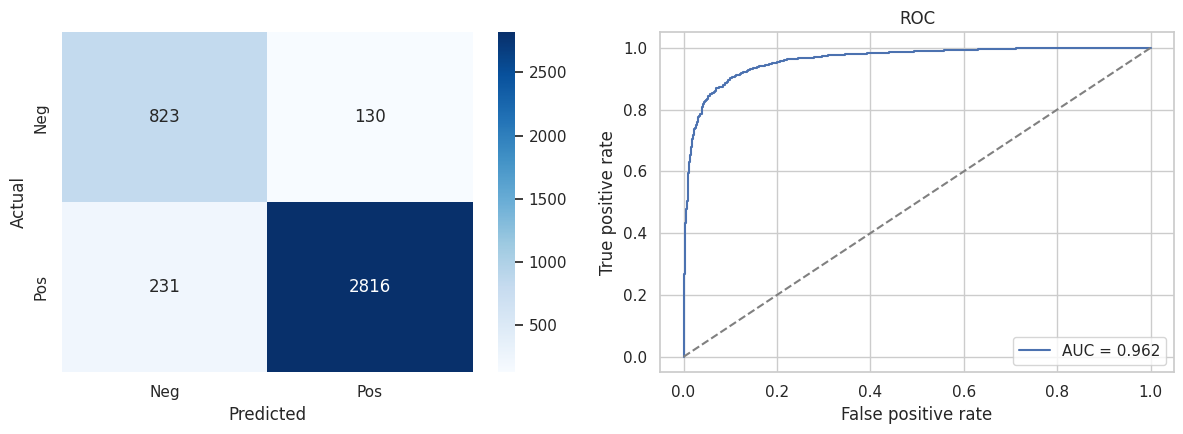

In [9]:
grid = GridSearchCV(
    Pipeline([("v", TfidfVectorizer(sublinear_tf=True, min_df=3)),
              ("c", LogisticRegression(max_iter=2000, class_weight="balanced"))]),
    {"v__ngram_range": [(1,1),(1,2)], "c__C": [0.5, 1, 2, 5]},
    scoring="f1_macro", cv=3, n_jobs=-1).fit(X_tr, y_tr)
best = grid.best_estimator_
print("Best:", grid.best_params_, "| CV macro-F1:", round(grid.best_score_, 3))

pred = best.predict(X_te); proba = best.predict_proba(X_te)[:,1]
print(classification_report(y_te, pred, target_names=["Negative","Positive"], digits=3))

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
sns.heatmap(confusion_matrix(y_te, pred), annot=True, fmt="d", cmap="Blues", ax=ax[0],
            xticklabels=["Neg","Pos"], yticklabels=["Neg","Pos"]); ax[0].set(xlabel="Predicted", ylabel="Actual")
fpr, tpr, _ = roc_curve(y_te, proba)
ax[1].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_te, proba):.3f}"); ax[1].plot([0,1],[0,1],"--",c="grey")
ax[1].set(xlabel="False positive rate", ylabel="True positive rate", title="ROC"); ax[1].legend()
plt.tight_layout(); plt.show()

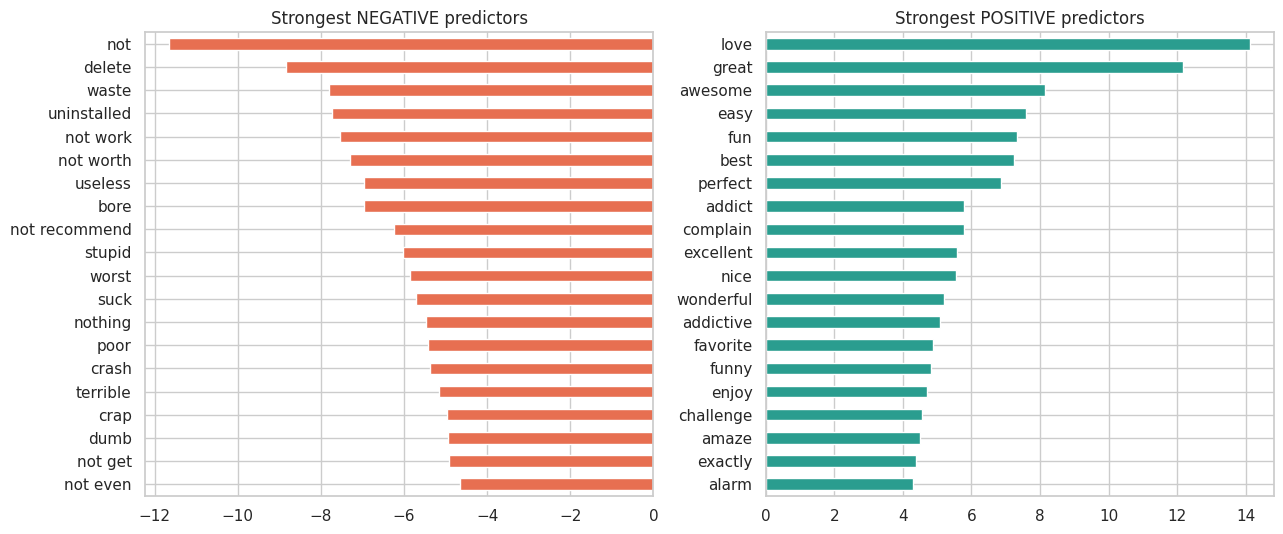

In [10]:
vec, clf = best.named_steps["v"], best.named_steps["c"]
coef = pd.Series(clf.coef_[0], index=vec.get_feature_names_out()).sort_values()
fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
coef.head(20)[::-1].plot.barh(ax=ax[0], color="#e76f51", title="Strongest NEGATIVE predictors")
coef.tail(20).plot.barh(ax=ax[1], color="#2a9d8f", title="Strongest POSITIVE predictors")
plt.tight_layout(); plt.show()

In [11]:
sia = SentimentIntensityAnalyzer()
df["vader"] = df["clean"].apply(lambda t: sia.polarity_scores(t)["compound"])
v_pred = (df.loc[X_te.index, "vader"] > 0).astype(int)
pd.DataFrame({
    "VADER (rule-based)":   [accuracy_score(y_te, v_pred), f1_score(y_te, v_pred, average="macro")],
    "TF-IDF + LogReg (ML)": [accuracy_score(y_te, pred),   f1_score(y_te, pred,   average="macro")],
}, index=["Accuracy", "Macro-F1"]).round(3)

,VADER (rule-based),TF-IDF + LogReg (ML)
Accuracy,0.83,0.91
Macro-F1,0.76,0.88


In [12]:
from sklearn.decomposition import LatentDirichletAllocation
neg_docs = df.loc[df.label == 0, "text"].apply(lambda t: " ".join(tokens(t, drop_domain=True)))
cv_lda = CountVectorizer(max_df=0.4, min_df=10)
Xn = cv_lda.fit_transform(neg_docs)
lda = LatentDirichletAllocation(n_components=5, random_state=RANDOM_STATE, max_iter=20).fit(Xn)
terms = cv_lda.get_feature_names_out()
share = pd.Series(lda.transform(Xn).argmax(1)).value_counts(normalize=True).sort_index()
for k, comp in enumerate(lda.components_):
    print(f"Topic {k} ({share.get(k,0):.0%}):", ", ".join(terms[comp.argsort()[::-1][:10]]))

Topic 0 (23%): free, like, play, pay, say, look, really, even, money, time
Topic 1 (21%): kindle, work, fire, download, try, time, play, close, force, go
Topic 2 (22%): waste, time, stupid, even, bore, ever, like, hate, think, really
Topic 3 (14%): very, star, like, bad, give, no, too, only, make, word
Topic 4 (20%): phone, use, work, need, android, no, amazon, install, run, version


,Reviews,% of negative reviews,% negative when mentioned,Lift
Theme,,,,
Device compatibility,5215,0.303,0.277,1.163
Boring / poor quality,1330,0.218,0.782,3.281
Crashes & bugs,1485,0.194,0.624,2.616
Value & money,2049,0.183,0.425,1.783
Churn signal (deleted),674,0.111,0.783,3.287
Usability & controls,1570,0.099,0.300,1.259
Updates,615,0.039,0.299,1.255
Ads & pop-ups,364,0.026,0.343,1.441


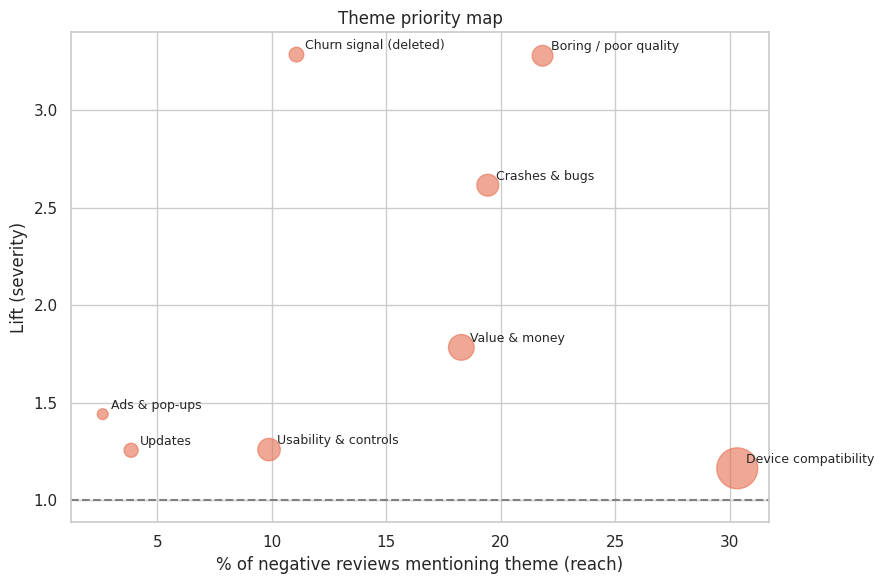

In [13]:
THEMES = {
 "Crashes & bugs":        r"\b(crash\w*|force clos\w*|freez\w*|froze\w*|glitch\w*|bugs?|buggy|lag\w*|errors?)\b|\bnot (work|working|open|load|loading|start|run|launch|download|install)\w*|\bstop(ped|s)? working\b",
 "Value & money":         r"\b(waste\w*|refund\w*|money|overpriced|rip ?off|scam|charged?|charges?|paid|pay|purchase\w*|cost\w*|price\w*)\b",
 "Device compatibility":  r"\b(kindle|fire|tablet|android|phone|device|compatib\w*|screen|samsung|nook|ipad|iphone)\b",
 "Usability & controls":  r"\b(confus\w*|difficult|hard|complicated|controls?|interface|navigat\w*|clunky|slow|tricky|frustrat\w*|annoying)\b",
 "Boring / poor quality": r"\b(boring|stupid|dumb|lame|useless|pointless|repetitive|garbage|junk|terrible|awful|horrible|sucks?|ridiculous)\b",
 "Ads & pop-ups":         r"\b(ads?|adverts?|advertis\w*|pop ?ups?|spam)\b",
 "Updates":               r"\b(update\w*|upgrade\w*|new version|latest version)\b",
 "Churn signal (deleted)": r"\b(uninstall\w*|deleted?|delete)\b",
}
base_neg, n_neg = (df.label == 0).mean(), (df.label == 0).sum()
rows = []
for th, pat in THEMES.items():
    m = df["clean"].str.contains(pat, regex=True)
    rows.append({"Theme": th, "Reviews": m.sum(),
                 "% of negative reviews": (m & (df.label == 0)).sum() / n_neg,
                 "% negative when mentioned": (df.loc[m, "label"] == 0).mean(),
                 "Lift": (df.loc[m, "label"] == 0).mean() / base_neg})
themes = pd.DataFrame(rows).set_index("Theme").sort_values("% of negative reviews", ascending=False)
display(themes.round(3))

plt.figure(figsize=(9, 6))
plt.scatter(themes["% of negative reviews"]*100, themes["Lift"], s=themes["Reviews"]/6, alpha=.6, color="#e76f51")
for th, r in themes.iterrows():
    plt.annotate(th, (r["% of negative reviews"]*100, r["Lift"]), xytext=(6,4), textcoords="offset points", fontsize=9)
plt.axhline(1, color="grey", ls="--")
plt.xlabel("% of negative reviews mentioning theme (reach)"); plt.ylabel("Lift (severity)")
plt.title("Theme priority map"); plt.tight_layout(); plt.show()

In [14]:
import gradio as gr

def theme_hits(text):
    c = clean_text(text)
    return [t for t, p in THEMES.items() if re.search(p, c)]

def analyze(review):
    if not review or not review.strip():
        return {}, "Please enter a review.", ""
    proc = " ".join(tokens(review))
    p_pos = float(best.predict_proba([proc])[0][1])
    v = sia.polarity_scores(clean_text(review))["compound"]
    words = set(proc.split())
    drivers = sorted([(w, c) for w, c in coef.items() if w in words], key=lambda kv: -abs(kv[1]))[:6]
    why = ", ".join(f"{w} ({'+' if c > 0 else '−'})" for w, c in drivers) or "no strong words found"
    info = f"Themes: {', '.join(theme_hits(review)) or 'none'}\nVADER score: {v:+.2f}\nInfluential words: {why}"
    action = "⚠️ Route to support team" if p_pos < 0.5 else "✅ No action needed"
    return {"Positive": p_pos, "Negative": 1 - p_pos}, action, info

def batch(file):
    d = pd.read_csv(file.name if hasattr(file, "name") else file)
    d["p_negative"] = 1 - best.predict_proba(d["text"].apply(lambda t: " ".join(tokens(t))))[:, 1]
    d["predicted"] = np.where(d["p_negative"] > 0.5, "Negative", "Positive")
    d["themes"] = d["text"].apply(lambda t: "; ".join(theme_hits(t)))
    d.to_csv("scored_reviews.csv", index=False)
    return d.head(50), "scored_reviews.csv"

with gr.Blocks(title="Review Sentiment Analyser") as demo:
    gr.Markdown("# Amazon App Review Sentiment Analyser")
    with gr.Tab("Single review"):
        inp = gr.Textbox(lines=4, label="Customer review")
        btn = gr.Button("Analyse", variant="primary")
        o1, o2, o3 = gr.Label(label="Sentiment"), gr.Textbox(label="Recommended action"), gr.Textbox(label="Why?", lines=3)
        btn.click(analyze, inp, [o1, o2, o3])
        gr.Examples(["Love this app, so easy to use and the graphics are great!",
                     "Keeps crashing on my Kindle Fire. Total waste of money, want a refund.",
                     "Fun at first but way too many ads."], inp)
    with gr.Tab("Batch CSV"):
        f = gr.File(label="CSV with a 'text' column"); go = gr.Button("Score reviews")
        tbl, dl = gr.Dataframe(), gr.File(label="Download scored file")
        go.click(batch, f, [tbl, dl])
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a0df9eb47295fc1a51.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
